# CS3630 Project 3: Vacuum Cleaning Robot (Fall 2026)
## Brief
- Due: **Thursday October 8th** on Gradescope
- Late due date: **Sunday October 11th**
- Hand-in: `main.py` to the **Project 3 code** assignment; your report (`project3_report.pptx` exported to PDF) to the **Project 3 report** assignment.

## Getting started
1. Create the course environment and install the requirements (full instructions in `README.md`):
   ```
   conda create -n cs3630_p3 python=3.12 graphviz -c conda-forge
   conda activate cs3630_p3
   python -m pip install -r requirements.txt
   ```
2. Open this notebook with the `cs3630_p3` kernel (VS Code or JupyterLab). **We do not support Colab for this assignment.**
3. All of the code you write lives in `main.py`. This notebook walks you through each step and runs sanity checks against your `main.py`. See "How to work on this project" below.
4. After Section 3.5, follow `webots/STUDENT_SETUP_AND_NAVIGATION.md` to watch your robot drive the lab in Webots (Section 3.6). Four report questions use it.

## Submission Instructions
1. Submit `main.py` (only that file, with that exact name) to the code assignment. Do not change any function's signature and do not add code outside the `START OF YOUR CODE` / `END OF YOUR CODE` markers: the autograder only keeps what is between the markers.
2. Answer every `REPORT QUESTIONS` item in `project3_report.pptx`, export it to PDF, and submit the PDF to the report assignment. Assign every question to the correct page.

## Grading
- **60 pts** autograded from `main.py` (the local checks in this notebook are a subset of the autograder).
- **60 pts + 2 extra credit** for the report, of which 10 pts are the four Webots questions (3.1b, 3.2b, 4.4, 5.3b).
- No score is given if your `main.py` does not import or the autograder cannot extract your code. Run the checks in this notebook before submitting.

## Introduction
Welcome to Project 3 of CS3630 (Fall 2026)!

In this project, we will be building a model for the state space of a mobile robot based on [the following dataset](https://www.cas.kth.se/COLD/cold-freiburg.html) from a lab in Freiburg Germany!  For this assignment we will focus only on the first room (Part A).

![Freiburg Map](https://www.cas.kth.se/COLD/images/maps/map_freiburg_a.png)
![Sample Freiburg Robot Picture](https://raw.githubusercontent.com/Antony-SS/FA2025-CS3630-Hosted-Images/refs/heads/main/project3/Screenshot%202025-09-05%20at%205.16.42%E2%80%AFPM%20Medium.jpeg)

 We want the robot to infer where it is in our state space given the previous state, sensor observations using Markov Decision Processes. The math & code for this section is based heavily upon the math in [Chapter 3](http://www.roboticsbook.org/S30_vacuum_intro.html) of the book, but applied to this dataset. **This math for this project is based on Chapter 3 of the textbook. Please refer to the textbook for questions about the math.**

**The four questions this project answers, in order.** How do we *write down* a probabilistic model of a robot (3.1, 3.2)? How do we *simulate* from it (3.3)? How do we *infer* the hidden state from what the robot observes (3.4)? How do we *decide* what to do (3.5)? Section 3.6 then shows all four on a robot in Webots.


## How to work on this project

All of the code you write lives in **`main.py`**. Every `TODO` is a function there (plus the two
table strings `prob_spec` and `sensor_spec`), to be filled in between its `START OF YOUR CODE` and
`END OF YOUR CODE` markers. Do not change any function's signature, and do not rely on helper
functions defined outside the markers: the autograder only keeps what is between them.

This notebook defines none of that code. It imports `main.py`, explains each step, and runs the
sanity checks from `project3_test.py` against your implementation. `%autoreload 2` is turned on
below, so after you edit and save `main.py` you can simply re-run a check cell -- no kernel restart
needed. (If a check keeps reporting a stale result, restart the kernel once.)

The `REPORT QUESTIONS` cells throughout this notebook are the questions in `project3_report.pptx`.

**Submit `main.py` to the code assignment on Gradescope, and the PDF export of
`project3_report.pptx` to the report assignment.**


In [52]:
%load_ext autoreload
%autoreload 2

import gtsam
import numpy as np
import pandas as pd
from main import (
    ACTIONS,
    GTSAM_MPE,
    LIGHT_LEVELS,
    ROOMS,
    VARIABLES,
    ancestral_sampling,
    calculate_value_function,
    control_tape_reward,
    create_action_series,
    create_bayes_net,
    create_custom_action_sequence,
    create_dbn,
    create_factor_graph,
    create_markov_chain,
    create_motion_model,
    create_sensor_series,
    create_simple_action_sequence,
    create_state_series,
    generate_reward_table,
    get_custom_policy,
    get_kitchen_start_prior,
    get_prior,
    get_test_policy,
    get_transition_prob,
    naive_MPE,
    plot_state_histogram,
    plot_time_complexity,
    policy_iteration,
    pretty,
    prob_spec,
    reward_function,
    rollout_reward,
    sensor_spec,
    show,
    simulate_multiple,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Import the sanity checks (they live in `project3_test.py`, next to `main.py`).

In [53]:
from project3_test import TestProject3, verify

np.random.seed(3630)
unit_test = TestProject3()

## Constructing State & Action Spaces
First let us construct our state and action spaces.  These define what states our robot can be in and what actions we can take.  Let's build it using the image below.  Each number represents a distinct room. Can you guess how many different possible actions we'll have based on the image?  

Each 
![Freiburg Map](https://www.cas.kth.se/COLD/images/maps/map_freiburg_a.png)

The constants below are defined at the top of `main.py` (don't change the variable names or values):

In [54]:
print("ROOMS:", ROOMS)
print("ACTIONS:", ACTIONS)
print("LIGHT_LEVELS:", LIGHT_LEVELS)

ROOMS: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
ACTIONS: ['2->1', '1->2', '2->3', '3->2', '2->4', '4->2', '2->5', '5->2', '2->6', '6->7', '7->6', '6->2', '2->9', '9->8', '8->9', '9->2']
LIGHT_LEVELS: ['dark', 'medium', 'light']


## Section 3.1: Modeling the State Space

*Question 1, write it down: what are the states and the actions?*

In this project, we will be creating mathematical models to predict the state of the robot in the Freiburg lab. Our goal will be to infer the state of the robot based on actions & observations over time.  Our robot operates under a discrete time series, and at each time step we will form a belief about where in the lab space our robot is. We’ve already defined our action & state space, now let’s turn those into GTSAM Variables so we can use some of the powerful tools the GTSAM API exposes.

In order to understand the API of Variables, run the following cell. We want to create a **discrete time series** to represent the robot's states and actions at each discrete timestep. This is a dictionary mapping timestep values to states/actions taken in the respective timestep.

In [55]:
help(VARIABLES)

Help on Variables in module gtbook.discrete object:

class Variables(builtins.object)
 |  A problem domain for discrete variables.
 |
 |  Methods defined here:
 |
 |  __init__(self)
 |      Default constructor
 |
 |  assignment(self: 'Variables', map: dict[tuple[int, int], str]) -> gtsam.gtsam.DiscreteValues
 |      Create a GTSAM assignment of keys to values.
 |
 |      Args:
 |          map (dict[DiscreteKey, str]): map from discrete keys to values.
 |
 |      Returns:
 |          gtsam.DiscreteValues: the GTSAM equivalent.
 |
 |  binary(self: 'Variables', name: str) -> tuple[int, int]
 |      Create a binary variable with given name.
 |
 |      Args:
 |          name (str): name of the variable.
 |
 |      Returns:
 |          DiscreteKey, i.e., (gtsam.Key, cardinality)
 |
 |  discrete(self, name: str, domain: list[str]) -> tuple[int, int]
 |      Create a variable with given name and discrete domain of named values.
 |
 |      Args:
 |          name (str): name of the variable.
 | 

Now, lets define methods to create the robot's states and actions at every timestep. We already defined ACTION and STATE constants at the top of the notebook.  See [chapter 3.1](https://www.roboticsbook.org/S31_vacuum_state.html#) for guidance on the next couple steps.

**TODO 1 and TODO 2** are in `main.py`: complete `create_action_series` and `create_state_series` between their markers, save the file, and run the checks below.

In [56]:
print(
    "TODO 1 create_action_series:",
    verify(unit_test.test_create_action_series, create_action_series),
)

TODO 1 create_action_series: "Correct"


In [57]:
print(
    "TODO 2 create_state_series:", verify(unit_test.test_create_state_series, create_state_series)
)

TODO 2 create_state_series: "Correct"


Let's see if your code properly creates the state and action series:

In [58]:
A = create_action_series("A", [1, 2, 3, 4])
print("Action series:", A)

X = create_state_series("X", [1, 2, 3, 4, 5])
print("State series:", X)

Action series: {1: (4683743612465315841, 16), 2: (4683743612465315842, 16), 3: (4683743612465315843, 16), 4: (4683743612465315844, 16)}
State series: {1: (6341068275337658369, 9), 2: (6341068275337658370, 9), 3: (6341068275337658371, 9), 4: (6341068275337658372, 9), 5: (6341068275337658373, 9)}


You should see a dict mapping each time step to some tuple of (Key, cardinality).  This key is a large integer and is just an efficient encoding the timestep and char where the char is stored in the most signifigant 8 bits.

While the map from Freiburg is nice, we can represent our state and action spaces as a graph, where each node is a state or room, and each action is a transition between these states.  Here's a simplified visual of our state and action space.  

![Graph Representation](https://raw.githubusercontent.com/Antony-SS/FA2025-CS3630-Hosted-Images/refs/heads/main/project3/state-diagram.png)

### REPORT QUESTIONS
1. Read [3.1.3](https://www.roboticsbook.org/S31_vacuum_state.html#bayesian-vs-frequentist-interpretations-or-probability) on frequentist vs. bayesian approaches to probablity. Then answer the following questions:

    *   Suppose I want to know if it will rain tomorrow.  Please explain a frequentist approach to this problem, then explain a bayesian approach.  

   *   Explain when a frequentist approach might be better.  Explain when a bayesian one might be better.

   *   Give an example from your everyday life where you might use a bayesian or frequentist approach.  
    *   For example, when I'm running I am constantly thinking about whether cars (especially in Atlanta) will obey their stop signs.  I'd argue that I'm using a bayesian approach here were given the noise of the engine, their approach speed, the style of the car, I make some estimate as to whether they'll stop. This is a belief I form based on previous knowledge and experiences, not a concious tally I'm keeping in my head.

2. Suppose our robot needs to charge every night, and the charger is located in the kitchen. The robot's robust software will route it to its charger at the end of the night with 100% probability (unfortunately in the real world things don't play nice like this). What is the prior probability distribution of the robot's state every morning?

## Section 3.2: Probabilistic Outcomes

*Question 1, continued: how does an action change the state? This is the motion model.*

Unfortunately, our robot cannot magically identify what room it is in. The outcome of its actions are probabilistic; there are transition probabilities for the robot to move between rooms. To model this uncertainty, we can create a **motion model** for the robot, defining the conditional probability of the robot reaching a certain state in the next timestep given the current state and action taken:

$P(X_{t + 1}|X_t, A_t)$

To find the next state given priors and motion model, we can do the following matrix multiplication:

$x_{t+1}=M_ax_{t}$

Let's walk through this equation:

- $x_t$ is our state vector at time $t$.  It is a probability distrubution over our state space at time at a give time.  Consider a simpler version of our model with two rooms.  The state vector $x_t=[0.25, 0.75]$ means that at time $t$ we believe that there is a 25% chance of our robot being in room 1, and a 75% chance of being in room 2.
- $M_a$ is our transition matrix, which holds the transition probabilities to go from each state to another state, given action A.  This is an N x N matrix where N is the size of our state space. Take a second to think about what that means, and maybe create an example matrix for yourself for case above. For the Freiburg robot many entries in this matrix will be 0, as it is only possible to reach a select few rooms from a given room.  Teleportation isn't possible yet!  Note that we must define $M_a$ for each action, meaning that the total individual probablities we must define is NxNxM where M is the size of our action space.  For the Freiburg example this will be quite a a lot of values: 9 x 9 x 16.  




**TODO 3** is in `main.py`: complete `create_motion_model`.

In [59]:
print(
    "TODO 3 create_motion_model:", verify(unit_test.test_create_motion_model, create_motion_model)
)

TODO 3 create_motion_model: "Correct"


## Creating our Transition Probabilities
This is the most interesting part, as these probabilities define how our robot will behave given an action sequence.  We're gonna make some assumptions and inferences to create our table of transfer probabilties.  First let's walk through how to format this table of probabilties.

In [60]:
# Here is an example motion model for a robot with 5 rooms and 4 actions (Left, Right, Up, Down)
# Each column corresponds to an action.  Once we have a specified action, we can find our transition
# matrix.

example_prob_spec = """
    1/0/0/0/0 2/8/0/0/0 1/0/0/0/0 2/0/0/8/0
    8/2/0/0/0 0/1/0/0/0 0/1/0/0/0 2/0/0/0/8
    0/0/1/0/0 0/0/2/8/0 0/0/1/0/0 0/0/1/0/0
    0/0/8/2/0 0/0/0/2/8 8/0/0/2/0 0/0/0/1/0
    0/0/0/8/2 0/0/0/0/1 0/8/0/0/2 0/0/0/0/1
"""

# Let us take the action Left as an example (first column).
# Row 1: ['1', '0', '0', '0', '0']
# Row 2: ['8', '2', '0', '0', '0']
# Row 3: ['0', '0', '1', '0', '0']
# Row 4: ['0', '0', '8', '2', '0']
# Row 5: ['0', '0', '0', '8', '2']

# Now we can read it as follows: The first row is the probability of moving from room 1 to rooms 1,
# 2, 3, 4, 5 respectively.
# As we can see in this case if we are in room 1, there is a 100% chance of staying in room 1 if we
# take the left action.

# Another example:
# The second row is the probability of moving from room 2 to rooms 1, 2, 3, 4, 5 respectively.
# As we can see in this case if we are in room 2, there is an 80% chance of moving to room 1 and a
# 20% chance of staying in room 2
# if we take the left action.

Now let's create a motion model for our Freiburg robot.  Based on our the map, we've come up with the following transition probabilties:

- 2->1: 1:0.93, 2:0.04, 3:0.03
- 1->2: 2:0.95, 1:0.03, 3:0.02
- 2->3 (kitchen, busy): 3:0.88, 2:0.06, 1:0.03, 4:0.03
- 3->2: 2:0.90, 3:0.05, 1:0.02, 4:0.03
- 2->4 (large office, heavy traffic): 4:0.87, 2:0.06, 5:0.04, 3:0.03
- 4->2: 2:0.90, 4:0.06, 5:0.02, 3:0.02
- 2->5: 5:0.92, 2:0.05, 4:0.02, 6:0.01
- 5->2: 2:0.94, 5:0.04, 4:0.01, 6:0.01
- 2->6: 6:0.93, 2:0.04, 7:0.02, 5:0.01
- 6->7: 2:0.05, 6:0.05 7:0.9 (doorways are close, could miss and go to 2 instead of 7)
- 7->6: 6:0.96, 7:0.04
- 6->2: 2:0.94, 6:0.04, 7:0.02
- 2->9 (stairs area, tricky): 9:0.88, 2:0.06, 8:0.04, 3:0.02
- 9->8: (really narrow) 8:0.92, 9:0.08
- 8->9: (really narrow) 8:0.07, 9:0.93
- 9->2: 2:0.90, 9:0.06, 8:0.04

**Notice that our robot's navigation software isn't perfect!  There is a non zero probabilty we slip into the wrong rooms.**  For instance, in the 2 -> 1 Action, there is a non zero probability we end up in room 3.  

Let's encode this into a table of similar format to the one above.  It will be quite large!  **If we take an action that dones't make sense in a given state, for example taking action 2 -> 1 in state 1 doesn't make sense, and in this case the robot will certainly remain in state 1.**

**TODO: fill in the two missing entries of `prob_spec`** in `main.py` (the `#####   FILL IN THESE TWO      #######` placeholder at the start of the first line: actions `2->1` and `1->2` taken from room 1). Keep the rest of the table as it is. The check below verifies the shape of the table and your two entries.

In [61]:
print("prob_spec:", verify(unit_test.test_create_prob_spec, prob_spec))

prob_spec: "Correct"


In [62]:
# Now we can create our motion model.
model = create_motion_model(X, A, prob_spec)
pretty(model)

X1,A1,1,2,3,4,5,6,7,8,9
1,2->1,1,0,0,0,0,0,0,0,0
1,1->2,0.03,0.95,0.02,0,0,0,0,0,0
1,2->3,1,0,0,0,0,0,0,0,0
1,3->2,1,0,0,0,0,0,0,0,0
1,2->4,1,0,0,0,0,0,0,0,0
1,4->2,1,0,0,0,0,0,0,0,0
1,2->5,1,0,0,0,0,0,0,0,0
1,5->2,1,0,0,0,0,0,0,0,0
1,2->6,1,0,0,0,0,0,0,0,0
1,6->7,1,0,0,0,0,0,0,0,0


Using this motion model, we can create a Discrete Bayes Net which provides a graphical interpretation of our state transition.

**TODO 4** is in `main.py`: complete `create_bayes_net`.

In [63]:
print("TODO 4 create_bayes_net:", verify(unit_test.test_create_bayes_net, create_bayes_net))

TODO 4 create_bayes_net: "Correct"


The diagram cells (`show(...)`) need the Graphviz `dot` program (installed with the `graphviz` conda package in the Getting started step). They are for your understanding only and are not graded.

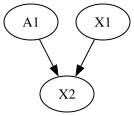

In [64]:
bayes_net = create_bayes_net(model)
show(bayes_net)

## REPORT QUESTIONS
1) It's the beginning of the day, and our robot undocks from the office charger. It chooses action "4->2" in order to clean the corridor. What is the probability that our robot DOES NOT end up in the hallway.

2) It's dinnertime and our robot has an 80/20 chance of being in rooms 5 or 6, respectively. It takes action "6->2". What is the PMF over the robot's resulting belief state?

3)  Notice that in the probability spec we created most rows only have 1 action for which the distribution that isn't 100/0/0/0 . . ..  However it seems room 2 has several actions for which the probability isn't 100/0/0 . . . etc.  What does this imply about the structure of our state space?

## Section 3.3: Dynamic Bayes Nets & Sensor Models

*Question 2, simulate: add a sensor model and roll the model forward in time.*

Now let's make make this a little more interesting.  So far we've only looked at probablities at one step in time.
However, in robotics applications we often analyzze at the evolution of our system over multiple time steps.
This is where Dynamic Bayes Nets come into play.
**When a Bayes net is used to unroll the evolution of a system or agent over time, we call it a dynamic Bayes net or DBN.**

Additionally, our robot has a light sensor on it! We've ignored it up until this point, but it is an extremely useful
tool in estimating our state. For example, if we detect low light levels, it is more likely we are in a room with few windows.
The more information we have the better. So far we've only used our previous state and action probability spec to
reason about our next state, now we're going to add the light sensor! This introduces the concept of observations
in our DBN as well, which result from the current state. 

First, we must create a discrete series for the sensor measurements:

**TODO 5** is in `main.py`: complete `create_sensor_series`.

In [65]:
print(
    "TODO 5 create_sensor_series:",
    verify(unit_test.test_create_sensor_series, create_sensor_series),
)

TODO 5 create_sensor_series: "Correct"


In [66]:
Z = create_sensor_series("Z", [1, 2, 3, 4, 5])
print("Measurement series:", Z)

Measurement series: {1: (6485183463413514241, 3), 2: (6485183463413514242, 3), 3: (6485183463413514243, 3), 4: (6485183463413514244, 3), 5: (6485183463413514245, 3)}


## 3.3.1 Creating our Sensor Spec
Now that we have our sensor series we must come up with our observation model, or sensor spec.
Given the room the robot is in, the observation model gives a probability distribution over the
measurements we might see there. More formally we define our observation model as:

$$
P(Z_t | X_t)
$$

where $X_t$ is the robot's state (room) at time $t$, and $Z_t$ is our measurement at time $t$.
The big idea here is as we record observations, we can take advantage of Bayes Law and find
$P(X_t | Z_t) \propto P(Z_t | X_t)(P(X_t))$, and find our probability distribution for $X_t$.
This is for one time step, keep in mind that unless we are on our first time step, $P(X_t)$ will rely on previous time step!
I hope you are starting to see how we can chain this system together over time, and how quickly it becomes complicated.
Good thing GTSAM takes care of most of the math under the hood for us!

So, let's define our sensor spec. Remeber, we only have 3 discrete measurements from our sensor (dark, medium, light)
and we need to defined $P(Z_t | x_t)$ for each possible state x (9 rooms).

Assume we're working from this model: 

- Room 1 (Printer area): 15/50/35 (dark: 15%, medium: 50%, light: 35%)
- Room 2 (Corridor): 20/60/20 (dark: 20%, medium: 60%, light: 20%)
- Room 3 (Kitchen): 15/45/40 (dark: 15%, medium: 45%, light: 40%)
- Room 4 (Large office): 20/55/25 (dark: 20%, medium: 55%, light: 25%)
- Room 5 (Two-person office): 20/55/25 (dark: 20%, medium: 55%, light: 25%)
- Room 6 (One-person office): 20/55/25 (dark: 20%, medium: 55%, light: 25%)
- Room 7 (One-person office): 20/55/25 (dark: 20%, medium: 55%, light: 25%)
- Room 8 (Bathroom): 40/50/10 (dark: 40%, medium: 50%, light: 10%)
- Room 9 (Stairs area): 60/35/5 (dark: 60%, medium: 35%, light: 5%)

`sensor_spec` is defined in `main.py` right after TODO 5. Compare it with the table above:

In [67]:
print(sensor_spec)


    15/50/35 20/60/20 15/45/40 20/55/25 20/55/25 20/55/25 20/55/25 40/50/10 60/35/5



Let's also create some priors. Define one prior that has a uniform distribution over all rooms, and another that reflects our robot always starting in the kitchen.

**TODO 6 and TODO 7** are in `main.py`: complete `get_prior` and `get_kitchen_start_prior`.

In [68]:
print("TODO 6 get_prior:", verify(unit_test.test_get_prior, get_prior))

TODO 6 get_prior: "Correct"


In [69]:
print(
    "TODO 7 get_kitchen_start_prior:",
    verify(unit_test.test_get_kitchen_start_prior, get_kitchen_start_prior),
)

TODO 7 get_kitchen_start_prior: "Correct"


Now, complete the create_dbn function that generates our DBN given priors, our states, actions, and observations, sensor and action Conditional Probability Tables, and N, the number of timesteps in the DBN.

**TODO 7 (`create_dbn`)** is in `main.py`. Read its docstring carefully: the order in which the conditionals are added matters to GTSAM.

In [70]:
print("TODO 7 create_dbn:", verify(unit_test.test_create_dbn, create_dbn))

TODO 7 create_dbn: "Correct"


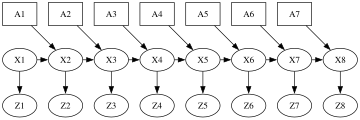

In [71]:
# NOTE: You may need to rerun this cell once in a while to reset your DBN.
# Also, feel free to test different priors when doing ancestral sampling.
priors = get_kitchen_start_prior()  # kitchen start prior

N = 8
X = create_state_series("X", range(1, N + 1))
A = create_action_series("A", range(1, N))
Z = create_sensor_series("Z", range(1, N + 1))
dbn = create_dbn(priors, X, A, Z, sensor_spec, prob_spec, N)
show(dbn, hints={"A": 2, "X": 1, "Z": 0}, boxes={A[k][0] for k in range(1, N)})

### What is ancestral sampling?
Ancestral sampling is done by performing state transformations from a topological sorting of the DBN. This is super useful for simulating what states and measurement trajectories we might get given a sequence of actions.  So, given a set of actions it will sample from the distributions we defined, and return a single trajectory each time we run it.  

This is simulation!  This is one useful thing we can do with DBNs. 

Notice what is given and what is sampled here: we fix the actions, and draw both the states and the measurements from the model. That is the opposite of the question a robot usually faces, where the actions and the measurements are known and the states are hidden. Answering that question is inference, and it is what Section 3.4 does with Bayes' rule on a factor graph. For now we are simulating.

We sample the initial state from the prior distribution $x_t \sim P(X_t)$, sample the observation from its Conditional Probability table $z_t \sim P(Z_t | X_t=x_t)$, and finally sample the next state from the motion model $x_{t + 1} \sim P(X_{t+1}|X_t=x_t, A_t=a_t)$.

To perform ancestral sampling let's first create some action sequences so that we can simulate our DBN. Follow the documentation at the top of the method definitions.

**TODO 8 and TODO 9** are in `main.py`: complete `create_simple_action_sequence` and `create_custom_action_sequence`.

In [72]:
print(
    "TODO 8 create_simple_action_sequence:",
    verify(unit_test.test_create_simple_action_sequence, create_simple_action_sequence),
)

TODO 8 create_simple_action_sequence: "Correct"


In [73]:
print(
    "TODO 9 create_custom_action_sequence:",
    verify(unit_test.test_create_custom_action_sequence, create_custom_action_sequence),
)

TODO 9 create_custom_action_sequence: "Correct"


In [74]:
create_custom_action_sequence(A, N - 1)

{(4683743612465315841, 16): '3->2',
 (4683743612465315842, 16): '2->6',
 (4683743612465315843, 16): '6->7',
 (4683743612465315844, 16): '7->6',
 (4683743612465315845, 16): '6->2',
 (4683743612465315846, 16): '2->3',
 (4683743612465315847, 16): '3->2'}

Now, lets use our DBN and an action sequence in order to perform ancestral sampling. Read the documentation in the method declaration to help you use the parameters.

**TODO 10** is in `main.py`: complete `ancestral_sampling`.

In [75]:
print("TODO 10 ancestral_sampling:", verify(unit_test.test_ancestral_sampling, ancestral_sampling))

TODO 10 ancestral_sampling: "Correct"


Test your implementation of ancestral sampling by using the simple action sequence and the custom action sequence.

In [76]:
# Change "test_action_sequence" using the two functions above
# i.e,  create_custom_action_sequence and create_simple_action_sequence

test_action_sequence = create_custom_action_sequence(A, N - 1)
# test_action_sequence = create_simple_action_sequence(A,N-1)

sample = ancestral_sampling(dbn, test_action_sequence)
pretty(
    sample
)  # this will print our trajectory from our sample of the DBN with the action sequence we provided,
# it will have our given actions and then sampled states, and measurements at each timestep.

Variable,value
A1,3->2
A2,2->6
A3,6->7
A4,7->6
A5,6->2
A6,2->3
A7,3->2
X1,3
X2,2
X3,7


Congrats! You have performed ancestral sampling with our robot!  Notice that you get a different trajectory every time you run it. Now that we can simulate our DBN, we can draw certain conclusions. 

Note that we can find the value of Variable from the sample using the following code:

In [77]:
var_name = "X"
timestep = 5
print(ROOMS[sample[gtsam.Symbol(var_name, timestep).key()]])

6


Now, write some code that runs ancestral sampling N times and returns the Kth state as a list.

**TODO 11** is in `main.py`: complete `simulate_multiple`.

In [78]:
print("TODO 11 simulate_multiple:", verify(unit_test.test_simulate_multiple, simulate_multiple))

TODO 11 simulate_multiple: "Correct"


In [79]:
result = simulate_multiple(dbn, create_custom_action_sequence(A, N - 1), 15, 1)
print(
    result
    # if you used the kitchen start prior and sample for the 1st state, you should always get 3, the
    # kitchen
)

['3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3', '3']


Let's plot our results in a bar graph.

**TODO 12** is in `main.py`: complete `plot_state_histogram`.

In [80]:
print(
    "TODO 12 plot_state_histogram:",
    verify(unit_test.test_plot_state_histogram, plot_state_histogram),
)

TODO 12 plot_state_histogram: "Correct"


In [81]:
plot_state_histogram(simulate_multiple(dbn, create_custom_action_sequence(A, N - 1), 1000, N))
# will open plot in a browser tab
# change the time step to see the distribution of states at that time step

### REPORT QUESTIONS
1) Compare the light sensor distributions for rooms 4 and 5 in `sensor_spec`. If the robot initially considers these rooms equally likely, can one light reading distinguish them? Explain how its previous room and action could still help.

2) Run ancestral sampling 1000 times to find the **final** state using the prior from get_kitchen_start_prior() and the action sequence from create_custom_action_sequence(). Plot a histogram with the results. What do you notice? Explain why we see the resulting distribution. Paste your histogram in your report.
3) Before a light reading, the robot assigns probability 0.8 to the kitchen (room 3) and 0.2 to the stairs area (room 9). It then observes "dark". Using the supplied sensor model (`sensor_spec`), calculate the posterior probability of each room. Why doesn't the room with the higher probability of producing a dark reading necessarily have the higher posterior probability?

**Webots questions (new in Fall 2026, see Section 3.6)**

3.1b) In Webots press `L` for LIGHT mode, then press `9` and later `3` to park the robot in the stairs area and the kitchen. For each room copy 10 consecutive `[LIGHT]` console lines and tally how often dark, medium and light occurred. Compare your two tallies with the room-9 and room-3 columns of `sensor_spec`. Which of the two (the `sensor_spec` column, your tally) is a frequentist quantity, and which is the modeling assumption a Bayesian uses as $P(Z|X)$? Include one screenshot with the robot in room 9 and the HUD visible.

3.2b) Press `T` for TAPE mode and watch the run until the `TAPE DONE` line appears in the console. Then press `T` again for a second run, and once that one is done, `T` a third time: each new run of a mode uses the next seed (3630, 3631, 3632), shown on the HUD and in the `TAPE DONE` line. Report the seed and final room for each of the three runs. Include one screenshot of a run that did NOT end in the kitchen. Using your histogram from 3.2, explain how surprising each of your three final rooms is.


## Section 3.4: Perception

*Question 3, infer: the same model, now run backwards from measurements to states.*

In this section, we address the **inference problem** in Hidden Markov Models (HMMs). Inference arises when some variables (such as the robot’s location) are hidden, and we want to recover their most likely values given the information we do have (actions and observations).

For the Freiburg Robot, this means estimating its most likely trajectory through the environment based on the sequence of actions it executed and the noisy light sensor measurements it received.  

A common method for solving this problem is **Maximum Probable Explanation (MPE)**. MPE finds the single most likely joint assignment of all hidden states. Unlike MAP (Maximum a Posteriori), which maximizes the probability of each variable marginally, MPE considers the *entire trajectory at once*. The trade-off is that MPE is computationally expensive in general (exponential in the number of states), but factor graph inference allows us to compute it efficiently in practice. Factor graphs are a graphical and more efficient representation of Bayesian relationships.

For more details on factor graphs see: [Factor Graphs](https://www.roboticsbook.org/S34_vacuum_perception.html#factor-graphs)

As in previous sections, we represent the HMM as a **factor graph**, where:
- The **prior factor** encodes the distribution over the initial state (which room the robot starts in).
- The **transition factors** encode the probabilities of moving between rooms given an action (in our dataset, actions are explicit transitions such as `"2->3"`, meaning a move from room 2 to room 3).
- The **sensor factors** encode the likelihood of observing a particular light level given the current room.

The probability of any trajectory is proportional to the product of these factors.  
In the next step, we will construct the factor graph by unrolling the DBN from Section 3.3 over `N` time steps, and then apply MPE inference to determine the Freiburg Robot’s most likely path.


**State Inference Diagram**:
   - Demonstrates how our belief about the robot's location changes over time
   - Initial belief has high confidence in kitchen location
   - After observing "medium" light level, belief shifts toward corridor
   - Final MPE state shows highest probability for corridor
   - Shows how observations and state transitions combine to update our beliefs

![Graph Representation](https://raw.githubusercontent.com/Antony-SS/FA2025-CS3630-Hosted-Images/refs/heads/main/project3/state_inference.png)

`create_factor_graph(N)` is provided in `main.py` (read it!). It returns the factor graph **and** the state series `X`. New this year: it also accepts `measurements=`, `actions=` and `prior=` keyword arguments, which the Webots MPE mode uses to pass real light readings; with no keyword arguments it builds the same kind of graph as before (one likelihood factor per state).

In [82]:
print(
    "create_factor_graph (provided; needs TODO 1, 2, 5, 9):",
    verify(unit_test.test_create_factor_graph, create_factor_graph),
)

create_factor_graph (provided; needs TODO 1, 2, 5, 9): "Correct"


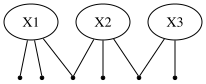

In [83]:
graph, _ = create_factor_graph(3)
show(graph)

Now that we've defined our factor graph, use the graph in order to find the maximum probable explanation (MPE) for state. Refer to the documentation in the method header which defines interactions between the parameters.

**TODO 13** is in `main.py`: complete `naive_MPE`. `generate_all_trajectories` is provided right above it.

In [84]:
print("TODO 13 naive_MPE:", verify(unit_test.test_naive_MPE, naive_MPE))

TODO 13 naive_MPE: "Correct"


In [85]:
N = 5
cur_graph, cur_X = create_factor_graph(N)
mpe_value, mpe_trajectory = naive_MPE(cur_graph, N, cur_X)
print(mpe_value)
for i in range(N):
    print(
        ROOMS[mpe_trajectory[gtsam.Symbol("X", i + 1).key()]]
    )  # this is the trajectory of the MPE

0.0017898408000000003
3
2
6
7
6


This is a naive MPE solution (try increasing N > 6 above and see what happens); GTSAM provides a more efficient solution. Let's implmenent the function to calculate the MPE using GTSAM. Check out DiscreteFactorGraph documentation for more information!

**TODO 14** is in `main.py`: complete `gtsam_MPE`.

In [86]:
print("TODO 14 GTSAM_MPE:", verify(unit_test.test_GTSAM_MPE, GTSAM_MPE))

TODO 14 GTSAM_MPE: "Correct"


In [87]:
N = 10
cur_graph, _ = create_factor_graph(N)
mpe_trajectory = GTSAM_MPE(cur_graph)

for i in range(N):
    print(
        ROOMS[mpe_trajectory[gtsam.Symbol("X", i + 1).key()]]
    )  # this is the trajectory of the MPE

3
2
6
7
6
2
3
2
6
7


Is Naive MPE or GTSAM MPE better? 🤔 Now let us run both the algorithms and capture the time taken for the given number of states. Compare the naive vs GTSAM implementation running times for 3 to 9 states. Look at the graph before for an understanding on what is expected. Please include the legend and Axis labels for full credit.


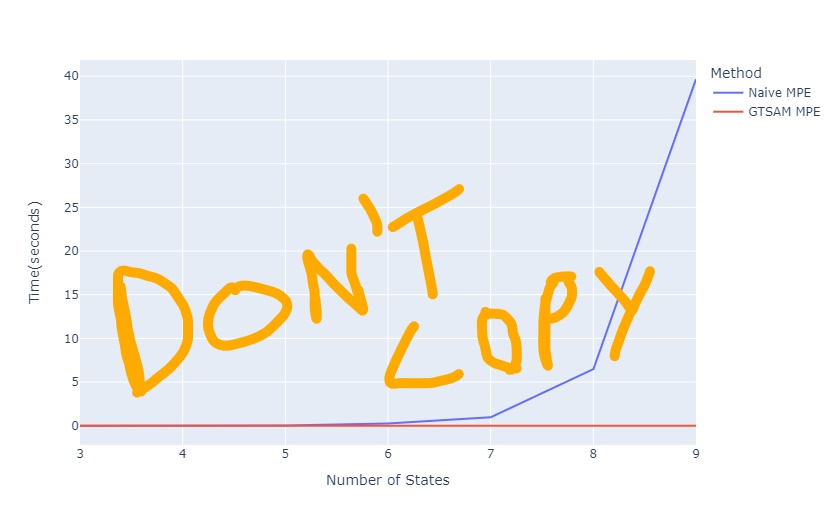

**TODO 15** is in `main.py`: complete `plot_time_complexity`. The autograder checks that your implementation calls `naive_MPE`, `GTSAM_MPE` and `create_factor_graph`, and plots with `px.line`.

In [88]:
print(
    "TODO 15 plot_time_complexity:",
    verify(unit_test.test_plot_time_complexity, plot_time_complexity),
)

TODO 15 plot_time_complexity: "Correct"


In [89]:
fig = plot_time_complexity()
fig.show()

A helper for the report questions below (and for Webots question 4.4): the sensor model and any column of the transition table, printed with room labels.

In [90]:
# Helper for the report questions: the two tables with labels.
def sensor_table():
    """P(Z | X) as a table: one row per room, one column per light level."""
    rows = [[float(v) for v in token.split("/")] for token in sensor_spec.split()]
    table = pd.DataFrame(rows, index=[f"room {r}" for r in ROOMS], columns=LIGHT_LEVELS)
    return table.div(table.sum(axis=1), axis=0).round(2)


def transition_table(action):
    """P(X' | X, A=action) as a table: one row per current room, one column per next room."""
    T = get_transition_prob(prob_spec)
    return pd.DataFrame(
        T[:, ACTIONS.index(action), :],
        index=[f"from {r}" for r in ROOMS],
        columns=[f"to {r}" for r in ROOMS],
    ).round(2)


print("P(Z | X): which light levels each room produces")
display(sensor_table())
print("P(X' | X, A='6->2'): change the action to look at another column of prob_spec")
display(transition_table("6->2"))

P(Z | X): which light levels each room produces


,dark,medium,light
room 1,0.15,0.50,0.35
room 2,0.20,0.60,0.20
room 3,0.15,0.45,0.40
room 4,0.20,0.55,0.25
room 5,0.20,0.55,0.25
room 6,0.20,0.55,0.25
room 7,0.20,0.55,0.25
room 8,0.40,0.50,0.10
room 9,0.60,0.35,0.05


P(X' | X, A='6->2'): change the action to look at another column of prob_spec


,to 1,to 2,to 3,to 4,to 5,to 6,to 7,to 8,to 9
from 1,1.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0
from 2,0.0,1.00,0.0,0.0,0.0,0.00,0.00,0.0,0.0
from 3,0.0,0.00,1.0,0.0,0.0,0.00,0.00,0.0,0.0
from 4,0.0,0.00,0.0,1.0,0.0,0.00,0.00,0.0,0.0
from 5,0.0,0.00,0.0,0.0,1.0,0.00,0.00,0.0,0.0
from 6,0.0,0.94,0.0,0.0,0.0,0.04,0.02,0.0,0.0
from 7,0.0,0.00,0.0,0.0,0.0,0.00,1.00,0.0,0.0
from 8,0.0,0.00,0.0,0.0,0.0,0.00,0.00,1.0,0.0
from 9,0.0,0.00,0.0,0.0,0.0,0.00,0.00,0.0,1.0


### REPORT QUESTIONS

1) What do the following factor graphs look like? Describe the structure or provide a sketch/diagram as appropriate.
- If all actions and measurements are unknown:
- If actions are known but measurements are unknown:
- If actions and measurements are unknown but the state series is known:

2) Plot the graph comparing the running time of naive MPE to GTSAM MPE.
(Insert the plot or a reference to the relevant figure.)

3) What is the time complexity of MPE when enumerating over N different number of states?
Choose one of the following:
- Linear (ax + c)
- Cubic (ax³ + c)
- Quintic (ax⁵ + c)
- Exponential (eˣ + c)

**Webots question (new in Fall 2026, see Section 3.6)**

*Before you answer 4.4.* Think carefully about what shapes the MPE. The transition factors place a strong prior on each action's intended outcome, so when a rare event (a wheel slipping on carpet, or on water or another liquid on the floor) leaves the robot where it was, or in a neighbouring room, instead of where the action pointed, the prior keeps voting for the intended path. The only thing that can correct the estimate is discriminative measurements: light readings that provide strong information about which room the robot is actually in. The `MPE RESULT` line prints both trajectory probabilities under your factor graph, and the helper cell above prints `sensor_spec` and `prob_spec` with labels.

4.4) Press `M` for MPE mode. Paste the `MPE RESULT` table from the console (step, action, light reading, true room, inferred room) and a screenshot of the final HUD. How many of the 8 rooms did `GTSAM_MPE` recover? Pick one step where the inferred room differs from the true room (or, if all match, the step with the least informative light reading) and explain, citing the relevant `sensor_spec` and `prob_spec` entries, why MPE chose that room.


## Section 3.5: Markov Decision Processes

*Question 4, decide: add a reward and choose actions instead of just predicting outcomes.*
As noted in the textbook, planning is the process of choosing control inputs; this leads us to the key concept of Markov Decision Processes. The decision of what actions our robot chooses to take are taken from a _policy_, which is determined by finding which future state may provide it the highest _reward_.

Suppose the kitchen area is very dirty. A potential reward function for our robot in this case would be 10 for entering the kitchen, and 0 for all other states.  We also need some starting state, which we assume to be room 2 (the corridor for now).

In learning, we also have a concept of a _policy rollout_; this is similar to simulating our DBN in section 3.3, except we apply transition probabilities and chosen actions to find a potential state sequence for the robot.

Using this rollout, a cumulative, discounted, _rollout reward_ for being in a certain state can be found.

The reward function and the rollout helpers (`reward_function`, `perform_rollout`, `reward`, `rollout_reward`, `get_transition_prob`) are provided in `main.py` at the start of Section 3.5. Read them before continuing; the cell below resets `N` to the horizon they assume.

In [91]:
N = 8
help(reward_function)
help(rollout_reward)

Help on function reward_function in module main:

reward_function(state: str, action: str, next_state: str) -> float
    Reward that returns 10 upon entering the Kitchen.

        Parameters:
            state (str): The current state the robot is in e.g. "2",
            meaning Room 2 -> the Corridor.
            action (str): The action the robot will take e.g. "2->3",
            meaning going from Room 2 (Corridor) to Room 3 (Kitchen).
            next_state (str) -> The resulting state the robot will be
            after taking ``action`` e.g. "3" meaning Room 3 (Kitchen).

        Returns:
            reward (float): the reward achieved. 10.0 if ``next_state``
            is kitchen; 0.0 if not kitchen.

Help on function rollout_reward in module main:

rollout_reward(R, rollout, A, X, horizon, gamma=1.0)
    Calculate reward for a given rollout



Let's also create a markov chain to describe our robot's sequence over time.

**TODO 16** is in `main.py`: complete `create_markovChain`.

In [92]:
print(
    "TODO 16 create_markovChain:", verify(unit_test.test_create_markov_chain, create_markov_chain)
)

TODO 16 create_markovChain: "Correct"


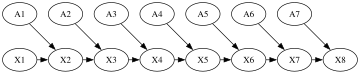

In [93]:
markov_chain = create_markov_chain(prob_spec, N)
show(markov_chain, hints={"A": 2, "X": 1, "Z": 0})

Now use the above functions and markov chain to find the expected reward from a sequence of actions

**TODO 17 and TODO 18** are in `main.py`: complete `generate_reward_table` and `control_tape_reward`.

In [94]:
print(
    "TODO 17 generate_reward_table:",
    verify(unit_test.test_generate_reward_table, generate_reward_table),
)

TODO 17 generate_reward_table: "Correct"


In [95]:
print(
    "TODO 18 control_tape_reward:", verify(unit_test.test_control_tape_reward, control_tape_reward)
)

TODO 18 control_tape_reward: "Correct"


In [96]:
N = 8
X = create_state_series("X", range(1, N + 1))
A = create_action_series("A", range(1, N))
markov_chain = create_markov_chain(prob_spec, N)

R = generate_reward_table(prob_spec)
actions_1 = {
    A[1]: "2->3",
    A[2]: "3->2",
    A[3]: "2->1",
    A[4]: "1->2",
    A[5]: "2->3",
    A[6]: "3->2",
    A[7]: "2->1",
}
actions_2 = {
    A[1]: "2->3",
    A[2]: "3->2",
    A[3]: "2->3",
    A[4]: "3->2",
    A[5]: "2->3",
    A[6]: "3->2",
    A[7]: "2->3",
}
print([float(control_tape_reward(markov_chain, "2", actions_1, R, A, X)) for _ in range(10)])
print([float(control_tape_reward(markov_chain, "2", actions_2, R, A, X)) for _ in range(10)])

[20.0, 20.0, 20.0, 30.0, 20.0, 20.0, 20.0, 20.0, 20.0, 10.0]
[40.0, 50.0, 40.0, 10.0, 50.0, 20.0, 30.0, 40.0, 40.0, 40.0]


We looked into to control tapes, but the fixed control tapes can never garuantee optimality because it can't be updated on the go. Now let us look into policies, which can be modified!

**TODO 19** is in `main.py`: complete `get_custom_policy`. The provided `get_test_policy`, `Q_value`, `calculate_value_system` and `calculate_value_function` follow it.

In [97]:
print("TODO 19 get_custom_policy:", verify(unit_test.test_get_custom_policy, get_custom_policy))

TODO 19 get_custom_policy: "Correct"


In [98]:
test_policy = get_custom_policy()  # replace with your policy using get_custom_policy()
T = get_transition_prob(prob_spec)
value_for_pi = calculate_value_function(
    test_policy,
    R,
    T,
)
print("Optimal Value Function:")
for i, room in enumerate(ROOMS):
    print(f"  {room:12}: {value_for_pi[i]}")

Optimal Value Function:
  1           : 43.102761673321154
  2           : 47.90843013461299
  3           : 43.182185724854335
  4           : 42.86330548442902
  5           : 42.532179788108024
  6           : 9.413296943742694
  7           : 8.436813858292206
  8           : 37.932519390336665
  9           : 42.46448108571739


Now we must find the optimal policy for our robot! Refer to the textbook on how to perform policy iteration.

**TODO 20** is in `main.py`: complete `policy_iteration` (`update_policy` is provided right above it).

In [99]:
print("TODO 20 policy_iteration:", verify(unit_test.test_policy_iteration, policy_iteration))

TODO 20 policy_iteration: "Correct"


In [100]:
policy = get_test_policy()  # replace with your policy using get_custom_policy()
optimal_policy, optimal_value_function = policy_iteration(R, T, policy)
print([ACTIONS[a] for a in optimal_policy])
print("The optimal values at each state when the optimal policy followed:")
for i, room in enumerate(ROOMS):
    print(f"  {room:12}: {optimal_value_function[i]}")

['1->2', '2->3', '2->1', '4->2', '5->2', '6->2', '7->6', '8->9', '9->2']
The optimal values at each state when the optimal policy followed:
  1           : 88.21002591427475
  2           : 98.04485990010448
  3           : 100.0
  4           : 87.7321024375339
  5           : 87.67957704568944
  6           : 87.5079860687138
  7           : 78.43039415287213
  8           : 77.62910491605903
  9           : 86.90378889647228


### REPORT QUESTIONS
1) What is a rollout? What is rollout reward? 

2) Compare the two control tapes provided after TODO 18. What is the optimal control tape? Why?

3) What is the optimal policy? Give a short explanation on what this policy tells us.

4) What's the objective of using policy iteration? What's the objective of using value iteration?

**Webots question (new in Fall 2026, see Section 3.6)**

*Before you answer 5.3b.* The reward is 10 whenever the *next* state is the kitchen, at every step, and an action that is not a doorway from the current room leaves the robot where it is. So once the robot is in the kitchen the best action is any action that does not lead out of it: the robot stays and collects 10 per step, $V(3) = 10/(1-0.9) = 100$, against about 43 for leaving and coming back. Policy iteration finds exactly this; the `2->1` it prints for room 3 is simply the first of the 15 tied "stay" actions. A robot parked in the kitchen is the policy working, and the console line `policy chose 2->1 in room 3: ... so the robot stays ...` says so.

5.3b) Press `8` and then `P` to run POLICY mode from the bathroom. Paste the `POLICY from policy_iteration()` console line and the eight `[POLICY]` step lines, and include a screenshot of the robot inside the kitchen with the cumulative reward visible on the HUD. Then answer: (a) From step 4 on the console reports `intended 1` but `sampled 3`. Using `calculate_value_function`, compare `V(3)` under the optimal policy with `V(3)` under a policy that uses `3->2` in the kitchen, and explain the numbers. (b) In 3.2b the control tape got stuck after a slip. Suppose the same kind of slip happened during this POLICY run, for example `9->2` leaving the robot in the stairs area: what would the policy do at the next step, and why can a policy recover where a control tape cannot? (c) Compare the realized total reward with `V(8)` printed by the controller and explain why they differ.


## Section 3.6: Watch your robot in Webots

Everything above lived in tables, samples and factor graphs. The `webots/` folder contains a Webots
world of the nine Freiburg rooms and an iRobot Create (a Roomba) whose controller **imports your
`main.py` and calls your functions live**. Nothing in Webots is autograded: the four report questions
3.1b, 3.2b, 4.4 and 5.3b ask for screenshots and console lines.

**Setup.** Follow `webots/STUDENT_SETUP_AND_NAVIGATION.md`: you already installed Webots R2025a in
Project 1B; point Webots' *Python command* preference at the `cs3630_p3` interpreter, then open
`webots/worlds/project3_vacuum.wbt` and press Run. Keep the `webots/` folder next to `main.py`.

**Modes.** Click the 3D view once so it has keyboard focus, then:

| Key | Mode | Section | Your functions it calls |
|---|---|---|---|
| `L` | LIGHT: park the robot and watch its light sensor | 3.3 sensor model | none |
| `T` | TAPE: replay the 6-step cycle with sampled outcomes | 3.3 ancestral sampling | `create_action_series`, `create_custom_action_sequence` |
| `M` | MPE: hidden trajectory, real readings, then inference | 3.4 perception | `create_factor_graph`, `GTSAM_MPE` |
| `P` | POLICY: follow `policy_iteration()` from a start room | 3.5 MDP | `generate_reward_table`, `get_transition_prob`, `policy_iteration` |
| `C` | CUSTOM: follow `get_custom_policy()` | 3.5 MDP | `get_custom_policy` |
| `1`-`9` | choose the start room (LIGHT and POLICY/CUSTOM) | | |
| `R` | replay the last run with the same seed (and clear the floor) | | |

Transitions are sampled from *your* `prob_spec` with a fixed seed, so a run is reproducible: the
seed is shown on the HUD and in every `... DONE` console line. The first run of each mode uses
seed 3630; pressing the same mode key again starts a new run with the next seed (3631, 3632, ...),
and `R` replays the last run. The light readings come from a real
Webots `LightSensor` under per-room lighting, discretized into dark / medium / light.

The cell below prints what the controller will compute from your `main.py`, so you can compare it
with the Webots console.


In [101]:
# What the Webots controller will compute from your main.py (compare with the Webots console).
T = get_transition_prob(prob_spec)
R = generate_reward_table(prob_spec)
opt_policy, opt_values = policy_iteration(R, T, get_test_policy())
print(
    "POLICY mode will follow:",
    {room: ACTIONS[a] for room, a in zip(ROOMS, opt_policy, strict=False)},
)
print(
    "V(start) for each room:",
    {room: round(float(v), 2) for room, v in zip(ROOMS, opt_values, strict=False)},
)
print("CUSTOM mode will follow:", [ACTIONS[a] for a in get_custom_policy()])
A = create_action_series("A", range(1, N))
print("TAPE / MPE modes will replay:", list(create_custom_action_sequence(A, N - 1).values()))

POLICY mode will follow: {'1': '1->2', '2': '2->3', '3': '2->1', '4': '4->2', '5': '5->2', '6': '6->2', '7': '7->6', '8': '8->9', '9': '9->2'}
V(start) for each room: {'1': 88.21, '2': 98.04, '3': 100.0, '4': 87.73, '5': 87.68, '6': 87.51, '7': 78.43, '8': 77.63, '9': 86.9}
CUSTOM mode will follow: ['1->2', '2->3', '3->2', '4->2', '5->2', '6->7', '7->6', '8->9', '9->2']
TAPE / MPE modes will replay: ['3->2', '2->6', '6->7', '7->6', '6->2', '2->3', '3->2']


In [102]:
optimal_policy, _ = policy_iteration(R, T)
V_optimal = calculate_value_function(optimal_policy, R, T)
modified_policy = np.array(optimal_policy).copy()
modified_policy[ROOMS.index("3")] = ACTIONS.index("3->2")
V_modified = calculate_value_function(modified_policy, R, T)
print("Optimal policy V(3):", V_optimal[ROOMS.index("3")])
print("Modified policy V(3):", V_modified[ROOMS.index("3")])

Optimal policy V(3): 100.0
Modified policy V(3): 43.18370623334034


YOU ARE DONE!!!🎉🎉🥳🎉🎉